In [1]:
"""Code to plot RL training in thinking experiments."""
import sys
import argparse
import os
import re
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import pandas as pd
sns.set_palette("colorblind")

In [2]:
# results_directory = "results-max_steps_50"
results_directory = "debug_results"
# results_directory = "debug_results-init_tf"
plot_actions = False


# Optional: set a set of labels to use for plot
base_to_label = {
    'pretrained-think': 'Pretrained-Think',
    'pretrained-nothink': 'Pretrained-NoThink',
    'scratch-think': 'Scratch-Think',
    'scratch-nothink': 'Scratch-NoThink'
}
# base_to_label = {}

data_list = []

for filename in os.listdir(results_directory):

    if ".npy" not in filename:
        continue

    if plot_actions and "-thinkactions.npy" not in filename:
        continue

    if not plot_actions and "-thinkactions.npy" in filename:
        continue

    base = "_".join(filename.split("_")[:-1])
    seed = re.findall(r"-?\d+", filename)[-1]

    if base in base_to_label:
        base = base_to_label[base]

    x = np.load(os.path.join(results_directory, filename))

    for t, val in enumerate(x):
        data_list.append({"timepoint": t, "value": val, "series": base, "run": seed})


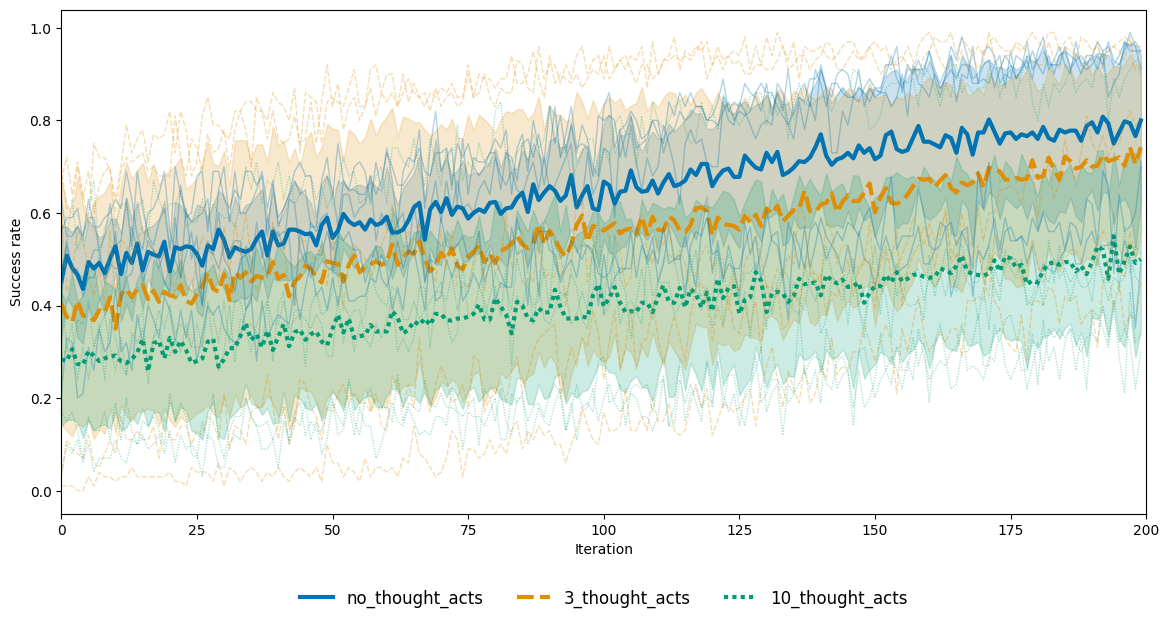

: 

In [ ]:
# Create DataFrame
df_all = pd.DataFrame(data_list)

df_all["series"] = df_all["series"].str.replace('test_thought_env-', '')
# df_all["series"] = df_all["series"].str.replace('test_output-aug_computation-', '')
# df_all = df_all[
#     (~df_all["series"].str.contains("no_thinking"))
#     | (
#         df_all["series"].str.contains("markov_tf")
#         & (~df_all["series"].str.contains("tf_layers_8"))
#     )
# ]


# df_all["line_style"] = np.where(
#     df_all["series"].str.contains("no_thinking", case=False, na=False),
#     "no_thinking",
#     "thinking",
# )
# df_all["line_style"] = np.where(
#     df_all["series"].str.contains("markov_tf", case=False, na=False),
#     "markov_tf",
#     df_all["line_style"],
# )

fig, ax = plt.subplots(figsize=(14, 8))
# Mean curves
sns.lineplot(
    data=df_all,
    x="timepoint",
    y="value",
    hue="series",
    style="series",
    estimator="mean",
    lw=3,
    errorbar="ci",
    ax=ax,
)

sns.lineplot(
    data=df_all,
    x="timepoint",
    y="value",
    hue="series",
    style="series",
    units="run",
    lw=1,
    estimator=None,
    alpha=0.3,
)

# Get only the series legend entries
handles, labels = ax.get_legend_handles_labels()

# Remove duplicates introduced by style=
series_handles = handles[:df_all["series"].nunique()]
series_labels = labels[:df_all["series"].nunique()]

# Add custom linestyle explanation
# series_handles += [
#     Line2D([0], [0], color="black", lw=3, linestyle="-"),
#     Line2D([0], [0], color="black", lw=3, linestyle="--"),
# ]
# series_labels += ["Thinking", "No Thinking"]

ax.legend(
    series_handles,
    series_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    ncol=5,
    fontsize=12,
    frameon=False,
    title=None,
)
ax.set_ylabel("Success rate")
ax.set_xlabel("Iteration")
ax.set_xlim(0, 200)

plt.subplots_adjust(bottom=0.25)
plt.show()